In [1]:
import os
import glob
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- VISUAL SETUP ---
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# --- CONFIGURATION ---
INPUT_WM_DIR = "Results/WorldModels/Search Results"
FINAL_OUTPUT_BASE = "Results/WorldModels"

def load_wm_results():
    """
    Reads all search results for the World Model.
    Returns summary DataFrame.
    """
    if not os.path.exists(INPUT_WM_DIR):
        print(f"❌ Directory not found: {INPUT_WM_DIR}")
        return pd.DataFrame()

    csv_files = glob.glob(os.path.join(INPUT_WM_DIR, "*_results.csv"))
    summary_data = []

    for csv_path in csv_files:
        try:
            file_name = os.path.basename(csv_path)
            idx = int(file_name.split("_")[0])
            
            # Load Data & Params
            df = pd.read_csv(csv_path)
            json_path = os.path.join(INPUT_WM_DIR, f"{idx}_params.json")
            with open(json_path, 'r') as f:
                params = json.load(f)
            
            # Get Final Loss (Last Epoch)
            final_loss = df.iloc[-1]['loss']
            
            entry = {"id": idx, "final_loss": final_loss, **params}
            summary_data.append(entry)
        except Exception as e:
            pass 

    if not summary_data:
        return pd.DataFrame()

    return pd.DataFrame(summary_data).sort_values("id").reset_index(drop=True)

C:\Users\Lennard\AppData\Roaming\Python\Python312\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.5)
  from scipy.stats import gaussian_kde


In [2]:
def plot_wm_search_overview(df):
    """
    Plots 1. Scatter of ID vs Loss, 2. Histogram of Losses.
    """
    if df.empty:
        print("No data to plot.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # 1. Scatter Plot (Lower loss is better, using reversed color map)
    sns.scatterplot(
        data=df, x="id", y="final_loss", hue="final_loss", 
        palette="viridis_r", s=100, edgecolor="black", ax=axes[0], legend=False
    )
    axes[0].set_title("World Model: Search Distribution", fontsize=14)
    axes[0].set_xlabel("Parameter Set ID")
    axes[0].set_ylabel("Final Loss (Lower is Better)")
    axes[0].grid(True, alpha=0.5)

    # 2. Histogram
    sns.histplot(
        data=df, x="final_loss", binwidth=0.01, 
        kde=True, color="purple", ax=axes[1]
    )
    axes[1].set_title("Loss Frequency Distribution", fontsize=14)
    axes[1].set_xlabel("Final Loss")
    axes[1].set_ylabel("Count")
    axes[1].grid(True, alpha=0.5)
    
    plt.tight_layout()
    plt.show()

def visualize_top_wm_curves(summary_df, top_n=5):
    """
    Plots detailed training curves (Loss vs Epoch) for the best models.
    """
    # Sort by Loss ASCENDING (Best first)
    top_df = summary_df.sort_values(by="final_loss", ascending=True).head(top_n).reset_index(drop=True)
    
    # Create Grid
    n_cols = min(top_n, 5)
    n_rows = (top_n + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(5 * n_cols, 4 * n_rows), sharey=False)
    if top_n == 1: axes = [axes] # Handle single plot case
    axes = np.array(axes).flatten()

    for i, row in top_df.iterrows():
        ax = axes[i]
        param_id = int(row['id'])
        final_loss = row['final_loss']
        
        # Load Time Series
        csv_path = os.path.join(INPUT_WM_DIR, f"{param_id}_results.csv")
        ts_df = pd.read_csv(csv_path)
        
        # Plot Curve
        ax.plot(ts_df['epoch'], ts_df['loss'], marker='o', linestyle='-', color='tab:red', linewidth=2)
        
        # Labels
        title_str = f"Rank {i+1} | ID {param_id}\nLoss: {final_loss:.4f}"
        ax.set_title(title_str, fontweight='bold')
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # Annotation for params
        excluded = ['id', 'final_loss']
        params_str = "\n".join([f"{k}: {v}" for k, v in row.items() if k not in excluded])
        # Add text box inside plot
        ax.text(0.95, 0.95, params_str, transform=ax.transAxes, fontsize=9,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
    
    # Print Text Summary
    print("\n" + "="*60)
    print("🏆 TOP PERFORMING CONFIGURATIONS")
    print("="*60)
    for i, row in top_df.iterrows():
        print(f"Rank {i+1}: ID {int(row['id'])} | Loss: {row['final_loss']:.4f}")
        excluded = ['id', 'final_loss']
        print(json.dumps({k:v for k,v in row.items() if k not in excluded}, indent=2))
        print("-" * 30)

def save_best_wm_params(params_dict):
    output_dir = FINAL_OUTPUT_BASE
    os.makedirs(output_dir, exist_ok=True)
    file_path = os.path.join(output_dir, "best_params.json")
    with open(file_path, 'w') as f:
        json.dump(params_dict, f, indent=4)
    print(f"✅ Params saved to: {file_path}")

Loaded 70 World Model configurations.


,id,final_loss,char_dim,mental_dim,batch_size,epochs,optimizer,lr
0,0,0.781858,16,16,16,20,Adam,0.001
1,1,0.643249,16,16,16,20,Adam,0.010
2,2,0.804397,16,16,16,20,RMSprop,0.001
3,3,0.619779,16,16,16,20,RMSprop,0.010
4,4,0.664869,16,16,16,50,Adam,0.001


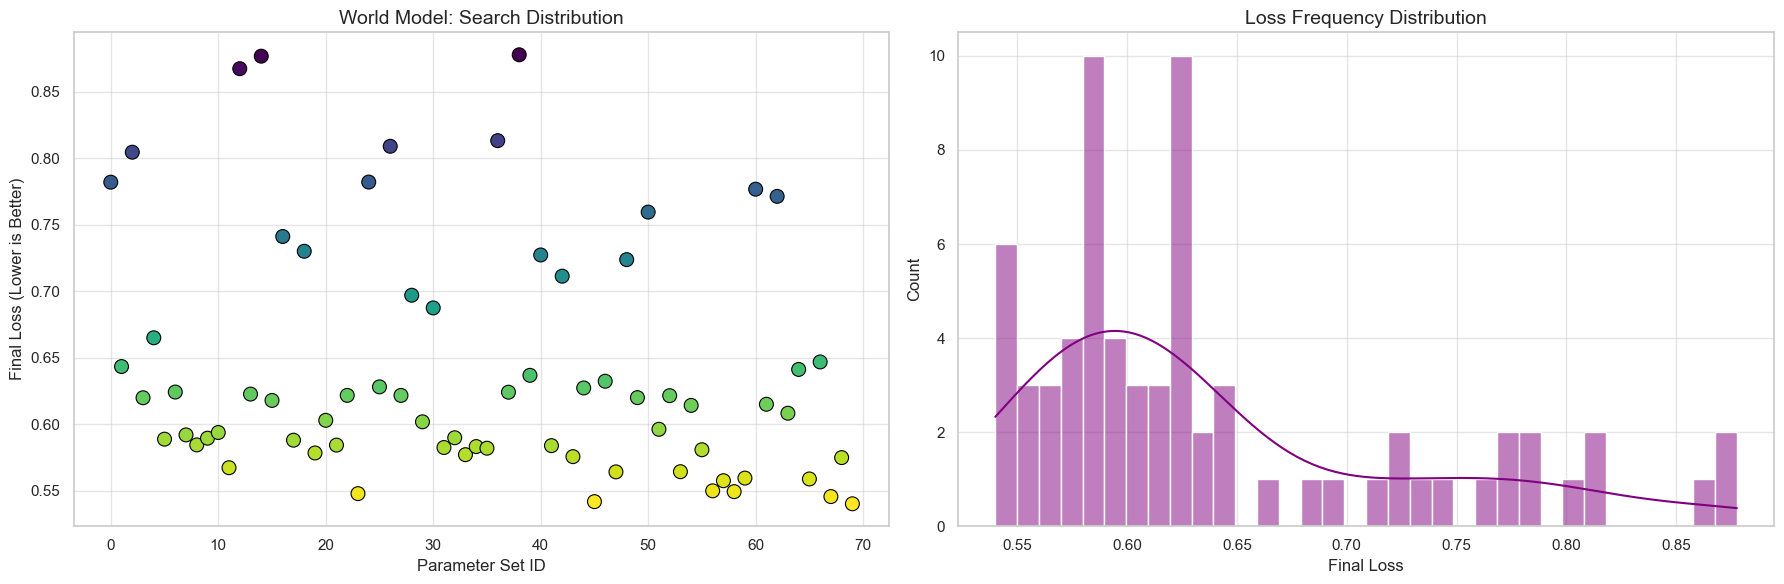

In [5]:
df_wm = load_wm_results()
print(f"Loaded {len(df_wm)} World Model configurations.")
display(df_wm.head())

plot_wm_search_overview(df_wm)

In [ ]:
TOP_X_MODELS = 5

In [ ]:
visualize_top_wm_curves(df_wm, top_n=TOP_X_MODELS)

In [ ]:
# PASTE YOUR CHOSEN PARAMETERS HERE
selected_wm_params = {
    "char_dim": 32,
    "mental_dim": 16,
    "batch_size": 32,
    "epochs": 20,
    "lr": 0.001,
    "optimizer": "Adam"
}

save_best_wm_params(selected_wm_params)